In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

losses = np.load(r"C:\Users\dlgkr\Downloads\train0319_1_losses.npz")
train_loss = losses['train_loss']
test_loss = losses['test_loss']
indv_losses = losses['indv_losses'][:, 1:]
train_loss : np.ndarray
test_loss : np.ndarray
indv_losses : np.ndarray

### Fundamental Drawings

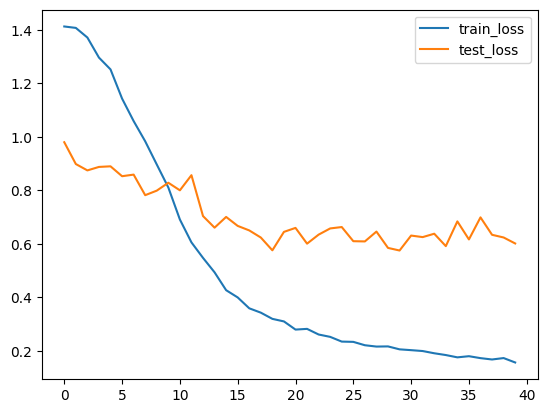

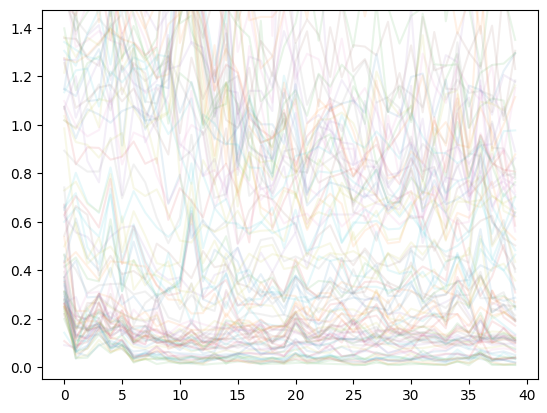

In [2]:
end_epoch = 40

plt.plot(train_loss[1:end_epoch+1], label='train_loss')
plt.plot(test_loss[1:end_epoch+1], label='test_loss')
plt.legend()
ylim = plt.ylim()
plt.show()

for i in range(indv_losses.shape[0]):
    plt.plot(indv_losses[i, 1:end_epoch+1], alpha=0.1)
plt.ylim((-0.05, ylim[1]))
plt.show()

### Advanced Drawings

#### Test Loss (avg, med w/ std) 

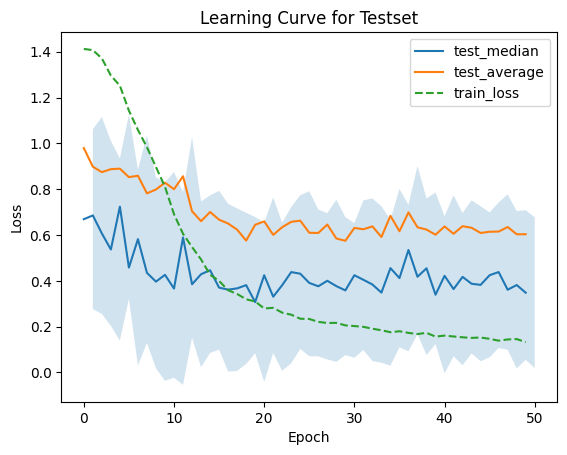

In [3]:
median = np.median(indv_losses, axis=0)
average = np.average(indv_losses, axis=0)
sigma = np.std(indv_losses, axis=0)

end_epoch = 50
sigma_ratio = 0.5
plt.plot(median[1:end_epoch+1], label='test_median')
plt.fill_between(np.arange(1, end_epoch+1),
                 median[1:end_epoch+1]-sigma_ratio*sigma[1:end_epoch+1],
                 median[1:end_epoch+1]+sigma_ratio*sigma[1:end_epoch+1], alpha=0.2)
plt.plot(average[1:end_epoch+1], label='test_average')
plt.plot(train_loss[1:end_epoch+1], linestyle='--', label='train_loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve for Testset")
plt.show()

#### Hist. for Loss Dist.

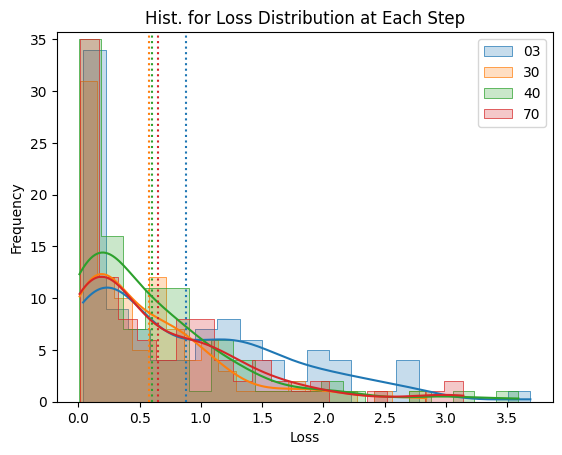

In [19]:
epoch_list = [3, 30, 40, 70]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
ylim = None
for epoch, color in zip(epoch_list, colors):
    sns.histplot(indv_losses[:, epoch], bins=20, kde=True, alpha=0.25, label="%02d"%(epoch), linewidth=0.5, element='step')
    ylim = plt.ylim() if ylim is None else ylim
    plt.plot([average[epoch]]*2, ylim, color=color, linestyle='dotted')
plt.ylim(ylim)
plt.xlabel("Loss")
plt.ylabel("Frequency")
plt.title("Hist. for Loss Distribution at Each Step")
plt.legend()
plt.show()